<a href="https://colab.research.google.com/github/smitha2908/smitha/blob/main/Student_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Student Marks.csv to Student Marks.csv


In [ ]:
import pandas as pd
df=pd.read_csv('Student Marks.csv')
print(df.head())


  Student Name  Tamil  English  Html  Java  Php  C++   C  Python
0       Smitha     87       92    91    81   98   77  94      86
1        Priya     45       65    78    78   68   54  56      56
2    Sathaniya     56       76    88    86   58   43  53      75
3         Manu     65       86    88    48   53   55  74      84
4         Maha     54       75    43    74   56   65  58      47


In [ ]:
subjects = ['Tamil', 'English', 'Html', 'Java', 'Php','C++','C','Python']

df['Total_Marks'] = df [subjects].sum(axis=1)

df['Average'] = df [subjects].mean(axis=1)

print(df[['Student Name', 'Total_Marks', 'Average']])


  Student Name  Total_Marks  Average
0       Smitha          706   88.250
1        Priya          500   62.500
2    Sathaniya          535   66.875
3         Manu          553   69.125
4         Maha          472   59.000
5      Karthik          158   19.750
6        Vijay          172   21.500
7         Arun          443   55.375
8         Siva          472   59.000


In [ ]:
def assign_grade (avg):
 if avg >= 90:
    return 'A+'
 elif avg >= 80:
    return 'A'
 elif avg >= 70:
    return 'B'
 elif avg >= 60:
    return 'C'
 elif avg >= 50:
   return 'D'
 else:
   return 'F'
df['Grade'] =df ['Average'].apply(assign_grade)
df['Status']= np.where(df['Average']>= 50, 'Pass', 'Fail')
print(df[['Student Name', 'Average', 'Grade', 'Status']])

  Student Name  Average Grade Status
0       Smitha   88.250     A   Pass
1        Priya   62.500     C   Pass
2    Sathaniya   66.875     C   Pass
3         Manu   69.125     C   Pass
4         Maha   59.000     D   Pass
5      Karthik   19.750     F   Fail
6        Vijay   21.500     F   Fail
7         Arun   55.375     D   Pass
8         Siva   59.000     D   Pass


In [ ]:
topper=df.loc[df['Average'].idxmax()]
print("Top Performer")
print("Name:", topper ['Student Name'])
print("Average:", topper ['Average'])
print("Grade:", topper ['Grade'])

Top Performer
Name: Smitha
Average: 88.25
Grade: A


In [ ]:
weak_students =df[df['Status'] =='Fail']
print("Weak Students")
print(weak_students [['Student Name', 'Average']])

Weak Students
  Student Name  Average
5      Karthik    19.75
6        Vijay    21.50


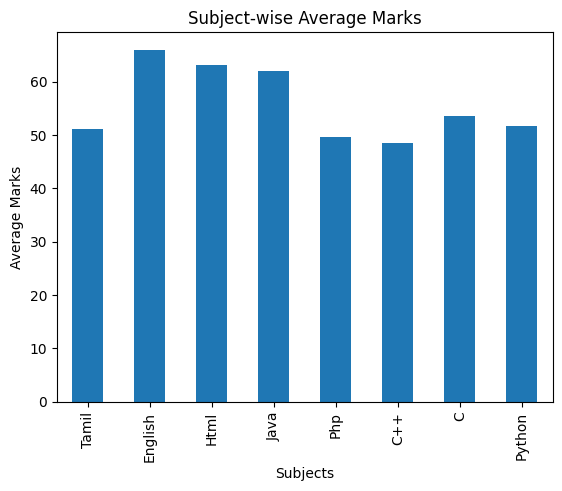

In [ ]:
subject_avg=df[['Tamil', 'English', 'Html', 'Java', 'Php','C++','C','Python']].mean()

subject_avg.plot(kind='bar')

plt.title("Subject-wise Average Marks")

plt.xlabel("Subjects")

plt.ylabel("Average Marks")

plt.show()

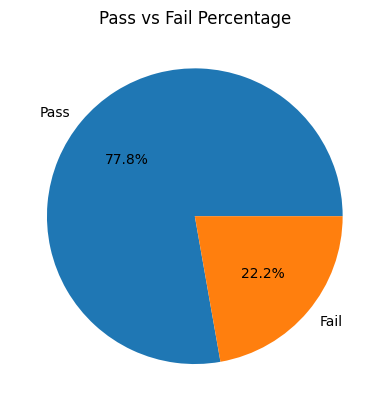

In [ ]:
status_count = df['Status'].value_counts()

plt.pie(status_count,
    labels=status_count.index,
    autopct='%1.1f%%')
plt.title("Pass vs Fail Percentage")
plt.show()

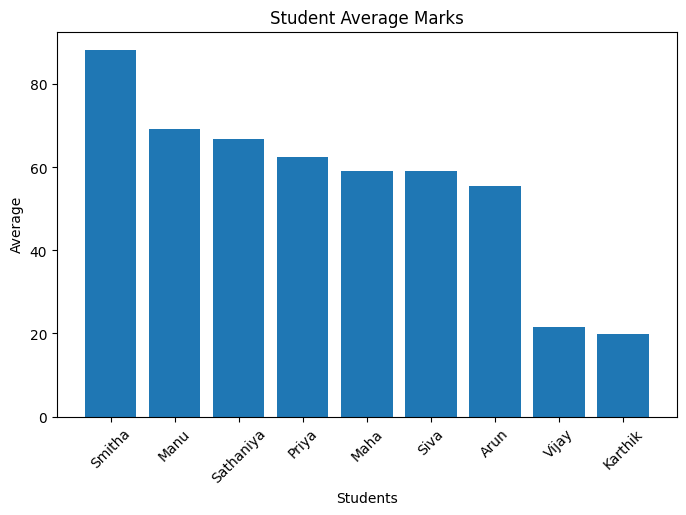

In [ ]:
top_students =df.sort_values (by='Average', ascending=False)
plt.figure(figsize=(8,5))
plt.bar(top_students['Student Name'],
        top_students['Average'])
plt.title("Student Average Marks")
plt.xlabel("Students")
plt.ylabel("Average")
plt.xticks (rotation=45)
plt.show()

In [ ]:


print("Highest Performing Subject:", subject_avg.idxmax())

print("Lowest Performing Subject:", subject_avg.idxmin())

print("Pass Percentage:", round((df['Status']=='Pass').mean()*100,2),"%")

print("Class Average:", round (df ['Average'].mean(),2))

Highest Performing Subject: English
Lowest Performing Subject: C++
Pass Percentage: 77.78 %
Class Average: 55.71


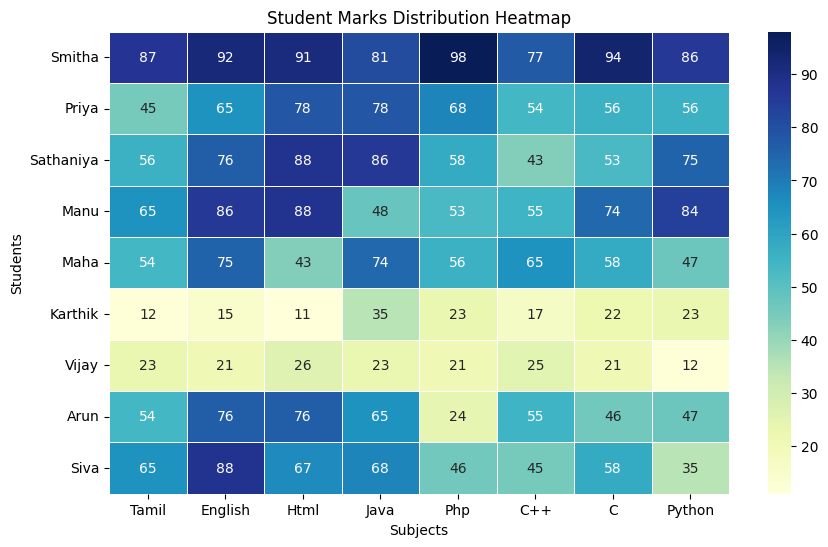

In [ ]:
# Student Marks Heatmap
plt.figure(figsize=(10, 6))
# Setting Student Name as the index so it shows on the y-axis
marks_heatmap_df = df.set_index('Student Name') [['Tamil', 'English', 'Html', 'Java', 'Php','C++','C','Python']]
# Generating the heatmap
sns.heatmap(marks_heatmap_df, annot= True, cmap='YlGnBu', fmt="g", linewidths=0.5)
plt.title('Student Marks Distribution Heatmap')
plt.ylabel('Students')
plt.xlabel('Subjects')
plt.show()

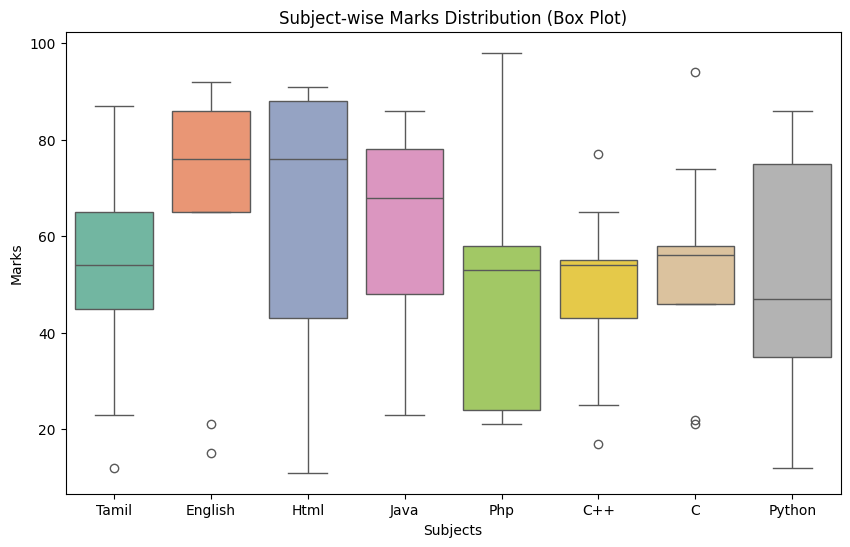

In [ ]:
#  Box Plot for Subject Marks Distribution
plt.figure(figsize=(10, 6))

# Melting or selecting data so seaborn can plot multiple columns easily
sns.boxplot(data=df[['Tamil', 'English', 'Html', 'Java', 'Php','C++','C','Python']], palette='Set2')

plt.title('Subject-wise Marks Distribution (Box Plot)')
plt.xlabel('Subjects')
plt.ylabel('Marks')
plt.show()

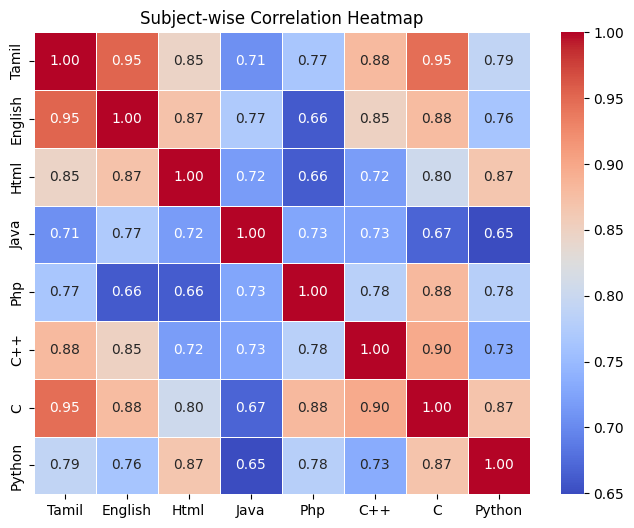

In [ ]:
# Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Subsetting only the subject marks columns for correlation
subjects_df = df[['Tamil', 'English', 'Html', 'Java', 'Php','C++','C','Python']]
correlation_matrix = subjects_df.corr()

# Generating the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Subject-wise Correlation Heatmap')
plt.show()